# Шаг 1. Причесываем данные

In [ ]:
import pandas as pd

users = pd.read_csv('/content/drive/MyDrive/apl/ab_test_users_groups.csv')
events = pd.read_csv('/content/drive/MyDrive/apl/ab_test_events.csv', parse_dates=['timestamp'])
users['signup_date'] = pd.to_datetime(users['signup_date'])

conflict_ids = users[users['user_id'].duplicated(keep=False)]['user_id'].unique()

events = events.drop_duplicates()

ev_counts = events.groupby('user_id').size()
bot_ids = ev_counts[ev_counts > 100].index

bad_ids = set(conflict_ids) | set(bot_ids)
users_clean = users[~users['user_id'].isin(bad_ids)]
events_clean = events[~events['user_id'].isin(bad_ids)]

merged = events_clean.merge(users_clean, on='user_id', how='left')

# Шаг 2. sanity check: проверяем, что нет пересечений между группами

In [ ]:
a_ids = set(users_clean[users_clean['group']=='A']['user_id'])
b_ids = set(users_clean[users_clean['group']=='B']['user_id'])
intersection = a_ids & b_ids
print(len(intersection))

0


# Шаг 3. Рассчет метрик на сырых данных

In [ ]:
from scipy import stats

counts = users_clean['group'].value_counts()
n_a, n_b = counts['A'], counts['B']
total = n_a + n_b

observed = [n_a, n_b]
expected = [total/2, total/2]

chi2, p_value = stats.chisquare(f_obs=observed, f_exp=expected)
print(p_value)

result = stats.binomtest(n_a, total, p=0.5)
print(result.pvalue)

0.9587469721447145
0.969054624493045


In [ ]:
event_counts = events_clean.groupby(['user_id', 'event_type']).size().unstack(fill_value=0)

metrics = event_counts.merge(users_clean, on='user_id', how='left')

metrics['completion_rate'] = metrics['homework_completed'] / metrics['homework_started'].replace(0, pd.NA)

metrics['returned_d7'] = (metrics['return_visit_d7'] > 0).astype(int)
metrics['returned_d14'] = (metrics['return_visit_d14'] > 0).astype(int)

# Шаг 4. воронка конверсии + распределения метрик

In [ ]:
for g in ['A','B']:
    sub = metrics[metrics['group']==g]
    n_total = len(sub)
    n_login = (sub['login']>0).sum()
    n_started = (sub['homework_started']>0).sum()
    n_completed = (sub['homework_completed']>0).sum()
    print(g, n_total, n_login, n_started, n_completed)

A 2992 2992 2992 2921
B 2988 2988 2988 2953


In [ ]:
metrics.groupby('group')['completion_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2992.0,0.346066,0.156056,0.0,0.250000,0.333333,0.444444,0.909091
B,2988.0,0.437967,0.180923,0.0,0.307692,0.444444,0.571429,1.000000


In [ ]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0001]
labels = ['0-20%','20-40%','40-60%','60-80%','80-100%']
metrics['cr_bucket'] = pd.cut(metrics['completion_rate'], bins=bins, labels=labels, include_lowest=True)

for g in ['A','B']:
    sub = metrics[metrics['group']==g]
    print(g)
    print(sub['cr_bucket'].value_counts(normalize=True))

A
cr_bucket
20-40%     0.474933
40-60%     0.277741
0-20%      0.193516
60-80%     0.050134
80-100%    0.003676
Name: proportion, dtype: float64
B
cr_bucket
40-60%     0.376506
20-40%     0.328648
60-80%     0.166332
0-20%      0.113119
80-100%    0.015395
Name: proportion, dtype: float64


In [ ]:
metrics.groupby('group')[['returned_d7','returned_d14']].mean()

,returned_d7,returned_d14
group,,
A,0.726939,0.288102
B,0.779786,0.362450


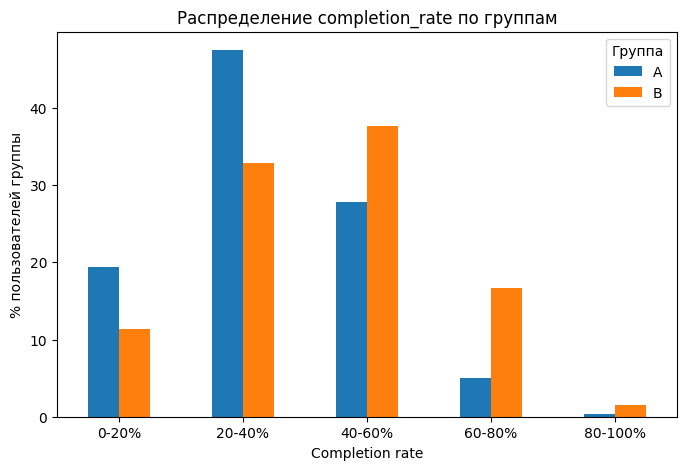

In [ ]:
import matplotlib.pyplot as plt

table = metrics.groupby('group')['cr_bucket'].value_counts(normalize=True).unstack() * 100

table.T.plot(kind='bar', figsize=(8,5))
plt.xlabel('Completion rate')
plt.ylabel('% пользователей группы')
plt.title('Распределение completion_rate по группам')
plt.xticks(rotation=0)
plt.legend(title='Группа')
plt.show()

# Шаг 5. Выбор критерия и его проверка

In [ ]:
from scipy import stats

for g in ['A','B']:
    cr = metrics[metrics['group']==g]['completion_rate']
    shapiro_stat, shapiro_p = stats.shapiro(cr) #это тест Шапиро-Уилка на нормальность распределения ген совокупности
    print(g, shapiro_p)

A 5.70222907976137e-11
B 7.239561072061459e-08




# Шаг 6. p-value и дов. интервалы

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

a = metrics[metrics['group']=='A']
b = metrics[metrics['group']=='B']

# t-тест Уэлча (вариант t-теста, не требующий равенства дисперсий групп — у нас они разные: 0.156 и 0.181)
t_stat, t_p = stats.ttest_ind(a['completion_rate'], b['completion_rate'], equal_var=False)

# Mann-Whitney U
u_stat, u_p = stats.mannwhitneyu(a['completion_rate'], b['completion_rate'], alternative='two-sided')

# z-тест для двух долей
count = [a['returned_d7'].sum(), b['returned_d7'].sum()]
nobs = [len(a), len(b)]
z_stat, z_p = proportions_ztest(count, nobs)

# хи-квадрат на таблице сопряжённости 2х2
table = pd.crosstab(metrics['group'], metrics['returned_d7'])
chi2, chi2_p, dof, expected = stats.chi2_contingency(table, correction=False)

print('=== COMPLETION RATE ===')
print(f'Группа A: среднее={a["completion_rate"].mean():.3f}')
print(f'Группа B: среднее={b["completion_rate"].mean():.3f}')
print(f't-тест: p-value={t_p:.2e}')
print(f'Mann-Whitney U: p-value={u_p:.2e}')
print()

print('=== RETENTION D7 ===')
print(f'Группа A: {a["returned_d7"].mean():.1%}')
print(f'Группа B: {b["returned_d7"].mean():.1%}')
print(f'z-тест: p-value={z_p:.2e}')
print(f'Хи-квадрат: p-value={chi2_p:.2e}')

=== COMPLETION RATE ===
Группа A: среднее=0.346
Группа B: среднее=0.438
t-тест: p-value=1.01e-94
Mann-Whitney U: p-value=8.56e-90

=== RETENTION D7 ===
Группа A: 72.7%
Группа B: 78.0%
z-тест: p-value=2.13e-06
Хи-квадрат: p-value=2.13e-06


In [ ]:
import numpy as np

mean_a, mean_b = a['completion_rate'].mean(), b['completion_rate'].mean()
var_a, var_b = a['completion_rate'].var(), b['completion_rate'].var()
n_a, n_b = len(a), len(b)

diff = mean_b - mean_a
se = np.sqrt(var_a/n_a + var_b/n_b)
ci_low, ci_high = diff - 1.96*se, diff + 1.96*se

p_a, p_b = a['returned_d7'].mean(), b['returned_d7'].mean()
diff_p = p_b - p_a
se_p = np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
ci_low_p, ci_high_p = diff_p - 1.96*se_p, diff_p + 1.96*se_p

print('completion_rate:', round(diff,4), 'CI95% = [', round(ci_low,4), ',', round(ci_high,4), ']')
print('returned_d7:', round(diff_p,4), 'CI95% = [', round(ci_low_p,4), ',', round(ci_high_p,4), ']')

completion_rate: 0.0919 CI95% = [ 0.0833 , 0.1005 ]
returned_d7: 0.0528 CI95% = [ 0.031 , 0.0747 ]


In [ ]:
z_alpha = stats.norm.ppf(1 - 0.05/2)
z_power = stats.norm.ppf(0.8)

mde_cr = (z_alpha + z_power) * se

# Шаг 7. интерпретация результатов

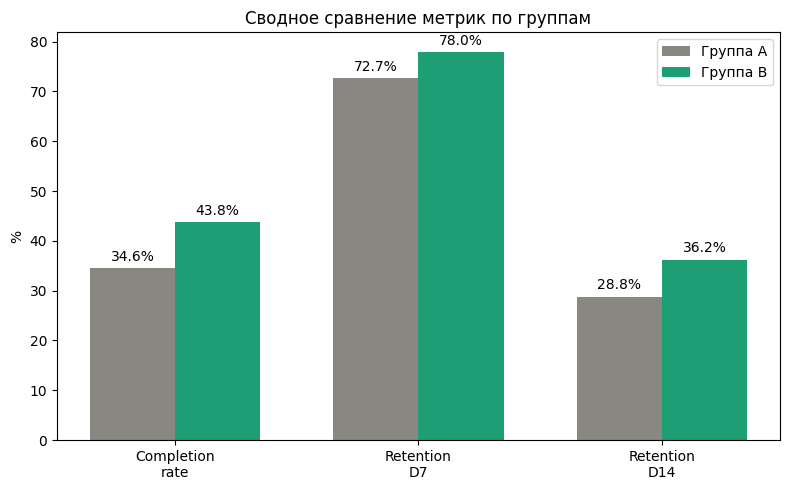

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Completion\nrate', 'Retention\nD7', 'Retention\nD14']
values_a = [a['completion_rate'].mean()*100, a['returned_d7'].mean()*100, a['returned_d14'].mean()*100]
values_b = [b['completion_rate'].mean()*100, b['returned_d7'].mean()*100, b['returned_d14'].mean()*100]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
bars_a = ax.bar(x - width/2, values_a, width, label='Группа A', color='#888780')
bars_b = ax.bar(x + width/2, values_b, width, label='Группа B', color='#1D9E75')

ax.set_ylabel('%')
ax.set_title('Сводное сравнение метрик по группам')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for bars in [bars_a, bars_b]:
    ax.bar_label(bars, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

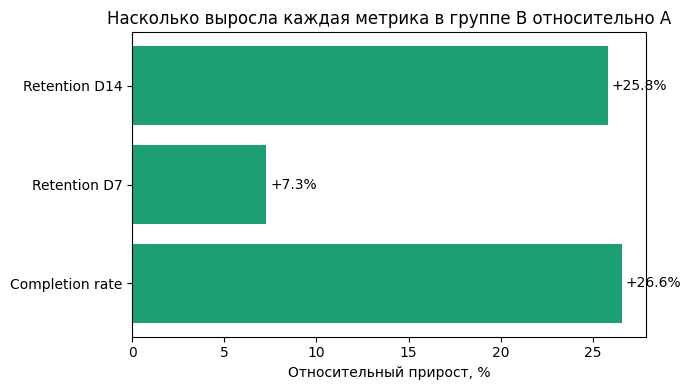

In [ ]:
lift_labels = ['Completion rate', 'Retention D7', 'Retention D14']
lift_values = [
    (b['completion_rate'].mean()/a['completion_rate'].mean() - 1) * 100,
    (b['returned_d7'].mean()/a['returned_d7'].mean() - 1) * 100,
    (b['returned_d14'].mean()/a['returned_d14'].mean() - 1) * 100
]

plt.figure(figsize=(7,4))
bars = plt.barh(lift_labels, lift_values, color='#1D9E75')
plt.xlabel('Относительный прирост, %')
plt.title('Насколько выросла каждая метрика в группе B относительно A')
plt.bar_label(bars, fmt='+%.1f%%', padding=3)
plt.tight_layout()
plt.show()